# AID-CLL Single-Cell — Anotación Celular y Análisis de Vías

**Objetivo:** anotar correctamente las células, definir el compartimento de **células B tumorales** y responder las 3 preguntas del estudio con **pruebas estadísticas formales**.

**Las 3 preguntas:**
1. ¿Qué células expresan programas relacionados con AID?
2. ¿Existe una subpoblación tumoral proliferativa?
3. ¿Están enriquecidas las vías **IFN-α**, **IFN-γ** y **KRAS** en células tumorales específicas? (diagnóstico vs refractario, *pooled*)

**Nota metodológica central:** el estudio tiene un **desbalance de composición** muy fuerte — el compartimento B tumoral en diagnóstico (≈8.500 células) es ~20× el de refractario (≈430). Para la pregunta 3 hacemos **dos** análisis: (a) la comparación completa y (b) una **comparación justa** submuestreando diagnóstico hasta igualar el número de refractario *por sujeto*, repetida 20 veces.

> Este notebook corrige la versión anterior (`cell_annotation.ipynb` original), cuya anotación mapeaba solo 9 de 12 clusters y estaba mal en 7 de 9 etiquetas.

## 1. Configuración

Cargamos todas las librerías y fijamos la semilla para reproducibilidad.

In [1]:
# ============================================================
# 1. CONFIGURACIÓN
# ============================================================
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)
library(viridis)
library(msigdbr)
library(fgsea)
library(DESeq2)
library(tibble)

set.seed(42)   # reproducibilidad

message("Librerías cargadas. ", R.version.string)

Loading required package: SeuratObject



Loading required package: sp



‘SeuratObject’ was built under R 4.6.0 but the current version is
4.6.1; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed




Attaching package: ‘SeuratObject’




The following objects are masked from ‘package:base’:

    intersect, t




...

The following objects are masked from ‘package:matrixStats’:

    anyMissing, rowMedians





Attaching package: ‘SummarizedExperiment’




The following object is masked from ‘package:Seurat’:

    Assays




The following object is masked from ‘package:SeuratObject’:

    Assays




Librerías cargadas. R version 4.6.1 (2026-06-24)



## 2. Carga del objeto mergeado

El objeto proviene del pipeline de preprocesamiento (**Seurat v5**) y tiene las capas **separadas por chip**: `counts.MV1`, `counts.MV2`, `data.MV1`, `data.MV2`.

> **Pitfall importante:** en Seurat v5, si no se hace `JoinLayers()` antes de `FetchData()`/`FeaturePlot()`, se pierden ~7.500 células (las de una capa).

In [2]:
# ============================================================
# 2. CARGA + UNIÓN DE CAPAS
# ============================================================
# Asegurar que el working directory es la raíz del repo (nbconvert/Jupyter
# puede arrancar en notebooks/, rompiendo las rutas relativas).
if (!file.exists("data/merged_MV12.rds") && file.exists("../data/merged_MV12.rds")) {
  setwd("..")
}

input_rds <- "data/merged_MV12.rds"
merged <- readRDS(input_rds)

# Unir capas split por chip (MV1/MV2) en una sola capa 'counts' y 'data'
merged <- JoinLayers(merged, assay = "RNA", layers = c("counts", "data"))

# Identidad activa = clustering a resolución 0.3
Idents(merged) <- "RNA_snn_res.0.3"

message("Células: ", ncol(merged), "  |  Genes: ", nrow(merged))

Células: 14550  |  Genes: 18543



## 3. Estructura y composición del objeto

Inspeccionamos la metadata y la composición por tipo celular (asignación **demux**) antes de anotar.

In [3]:
# ============================================================
# 3. ESTRUCTURA DEL OBJETO
# ============================================================
cat("Columnas de metadata:\n")
print(colnames(merged@meta.data))

cat("\nTamaño de clusters (res 0.3):\n")
print(table(merged$RNA_snn_res.0.3))

cat("\nComposición por tipo celular (demux):\n")
print(table(merged$celltype_demux))

cat("\nMuestras (sample_id x status):\n")
print(table(merged$sample_id, merged$status))

Columnas de metadata:


 [1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "chip"           
 [5] "subject"         "sample_id"       "celltype_demux"  "percent.mt"     
 [9] "percent.ribo"    "status"          "S.Score"         "G2M.Score"      
[13] "Phase"           "CC.Difference"   "RNA_snn_res.0.3" "RNA_snn_res.0.5"
[17] "RNA_snn_res.0.8" "RNA_snn_res.1"   "seurat_clusters"



Tamaño de clusters (res 0.3):



   0    1    2    3    4    5    6    7    8    9   10   11 
3227 2709 2352 1826 1737  802  671  626  219  190  104   87 



Composición por tipo celular (demux):



   Bcell   NKcell TcellCD4 TcellCD8     mega monocyte 
    9991      283     1590     2450       54      182 



Muestras (sample_id x status):


                 
                  diagnosis refractory
  S457_diagnosis       3425          0
  S457_refractory         0       1021
  S477_diagnosis       5984          0
  S477_refractory         0       4120


## 4. Anotación celular corregida

**Estrategia:** combinar (a) las etiquetas **demux** (asignación computacional validada a partir del perfil de expresión) con (b) **marcadores canónicos** para refinar.

Primero visualizamos los marcadores por cluster para anotar con evidencia, no con suposiciones.

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


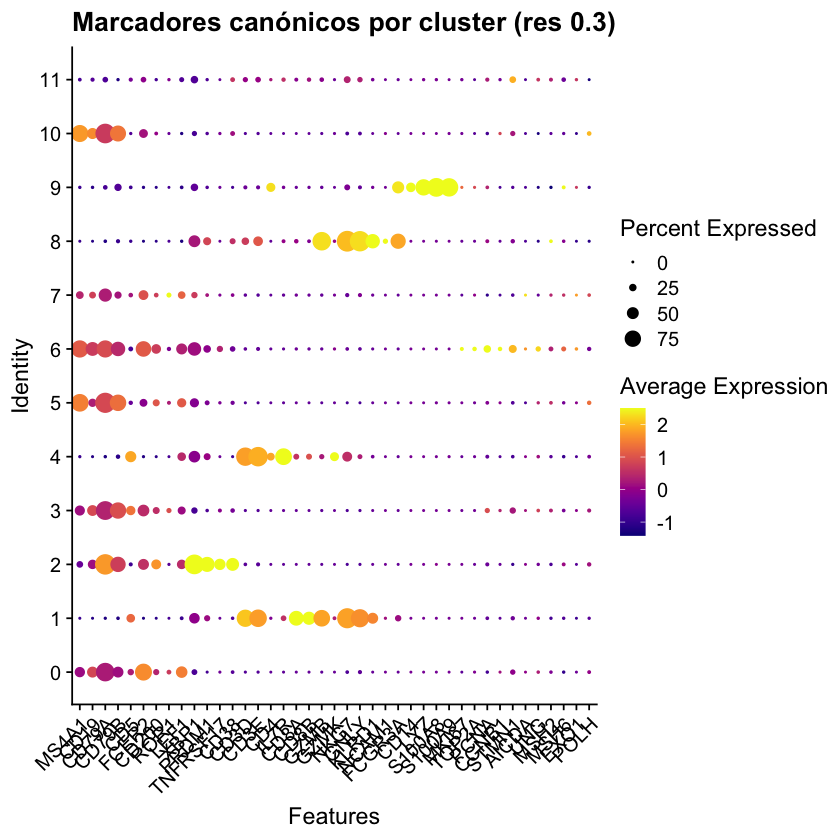

In [4]:
# ============================================================
# 4a. MARCADORES CANÓNICOS POR CLUSTER
# ============================================================
canonical_markers <- list(
  B_general     = c("MS4A1","CD19","CD79A","CD79B"),
  CLL_hallmark  = c("CD5","FCER2","CD200","ROR1","LEF1"),   # FCER2 = CD23
  Plasma        = c("XBP1","PRDM1","TNFRSF17","CD38"),
  T_CD4         = c("CD3D","CD3E","CD4","IL7R"),
  T_CD8         = c("CD3D","CD8A","CD8B","GZMB","GZMK"),
  NK            = c("NKG7","GNLY","KLRD1","NCAM1","FCGR3A"),
  Monocyte      = c("CD14","LYZ","S100A8","S100A9"),
  Proliferating = c("MKI67","TOP2A","PCNA","CCNB1","STMN1"),
  AID_machinery = c("AICDA","UNG","MSH2","MSH6","EXO1","POLH")
)

DotPlot(merged, features = unique(unlist(canonical_markers)),
        group.by = "RNA_snn_res.0.3", dot.scale = 5) +
  RotatedAxis() + scale_color_viridis(option = "plasma") +
  ggtitle("Marcadores canónicos por cluster (res 0.3)")

### Mapeo cluster → tipo celular

La evidencia de marcadores + demux da el siguiente mapeo (los 12 clusters, no solo 9):

| cluster | evidencia | etiqueta |
|---|---|---|
| 0, 3, 5, 7, 10 | CD79A+/MS4A1+/FCER2(CD23)+ | **CLL_B** |
| 2 | CD79A++ + XBP1/PRDM1/TNFRSF17/CD38 (pre-plasmablástico) | **CLL_B_plasma** |
| 6 | B + MKI67/TOP2A/PCNA/STMN1 | **CLL_B_prolif** |
| 1 | CD3D/E + CD8A/B + NKG7/GZMB | **CD8_T** |
| 4 | CD3D/E + CD4 + GZMK | **CD4_T** |
| 8 | NKG7/GNLY/KLRD1 | **NK** |
| 9 | CD14/LYZ/S100A8 | **Monocyte** |
| 11 | megacariocito (46) + NK (20) mixto | **Mega_NK** |

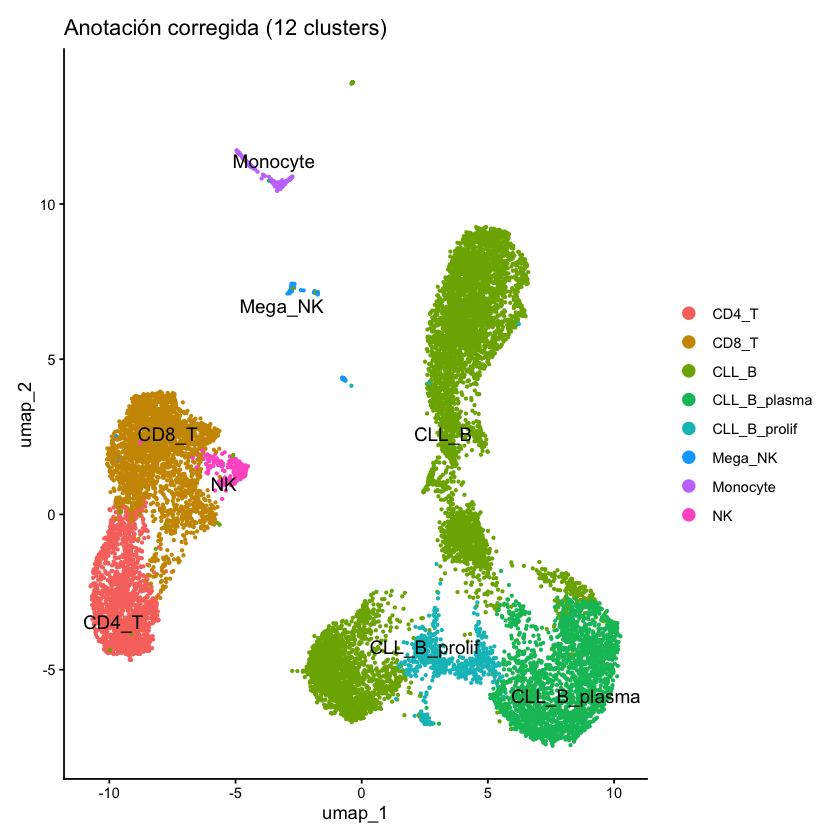

In [5]:
# ============================================================
# 4b. APLICAR ANOTACIÓN
# ============================================================
cluster_annotation <- c(
  "0"  = "CLL_B", "1" = "CD8_T", "2" = "CLL_B_plasma", "3" = "CLL_B",
  "4"  = "CD4_T", "5" = "CLL_B", "6" = "CLL_B_prolif", "7" = "CLL_B",
  "8"  = "NK", "9" = "Monocyte", "10" = "CLL_B", "11" = "Mega_NK"
)
merged$cell_type <- unname(cluster_annotation[as.character(merged$RNA_snn_res.0.3)])

DimPlot(merged, reduction = "umap", group.by = "cell_type",
        label = TRUE, repel = TRUE, pt.size = 0.4) +
  ggtitle("Anotación corregida (12 clusters)") + theme_classic()

## 5. Definición de células B tumorales

> **Sí, todas las comparaciones de la pregunta 3 son SOLO sobre células B tumorales.**

El compartimento tumoral se define como **células B (demux) que expresan ≥1 marcador B** (`MS4A1`/`CD79A`/`CD19`). Como la fracción clonal es 80–96%, la gran mayoría de las B de sangre son la clona de CLL. Exigir el marcador B descarta posibles dobletes/células mal clasificadas (p. ej. B dentro del cluster CD8_T).

In [6]:
# ============================================================
# 5. CÉLULAS B TUMORALES
# ============================================================
bmark <- FetchData(merged, vars = c("MS4A1","CD79A","CD19"))
merged$is_tumorB <- merged$celltype_demux == "Bcell" &
  (bmark$MS4A1 > 0 | bmark$CD79A > 0 | bmark$CD19 > 0)

cat("Células B (demux):", sum(merged$celltype_demux == "Bcell"), "\n")
cat("B tumorales (con marcador B):", sum(merged$is_tumorB), "\n")
cat("B tumorales por status:\n")
print(table(merged$status[merged$is_tumorB]))
cat("\nB tumorales por sujeto x status:\n")
print(table(merged$subject[merged$is_tumorB], merged$status[merged$is_tumorB]))

Células B (demux): 9991 


B tumorales (con marcador B): 8954 


B tumorales por status:



 diagnosis refractory 
      8521        433 



B tumorales por sujeto x status:


      
       diagnosis refractory
  S457      3092        323
  S477      5429        110


## 6. Q1 — ¿Qué células expresan programas relacionados con AID?

**AICDA (AID)** es ultra-raro en scRNA: se detecta en una fracción ínfima de células. Además de AICDA, evaluamos el **programa AID amplio** (maquinaria de CSR/SHM: UNG, MSH2/6, EXO1, POLH, APOBEC3).

AICDA>0 (todas las células): 20 = 0.137 %



AICDA>0 entre B tumorales, por tipo:



       CLL_B CLL_B_plasma CLL_B_prolif 
           9            2            6 



Score medio del programa AID por tipo celular:


CLL_B_prolif        CLL_B        CD8_T           NK     Monocyte        CD4_T 
      0.0300       0.0019      -0.0016      -0.0052      -0.0096      -0.0127 
CLL_B_plasma      Mega_NK 
     -0.0193      -0.0286 


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


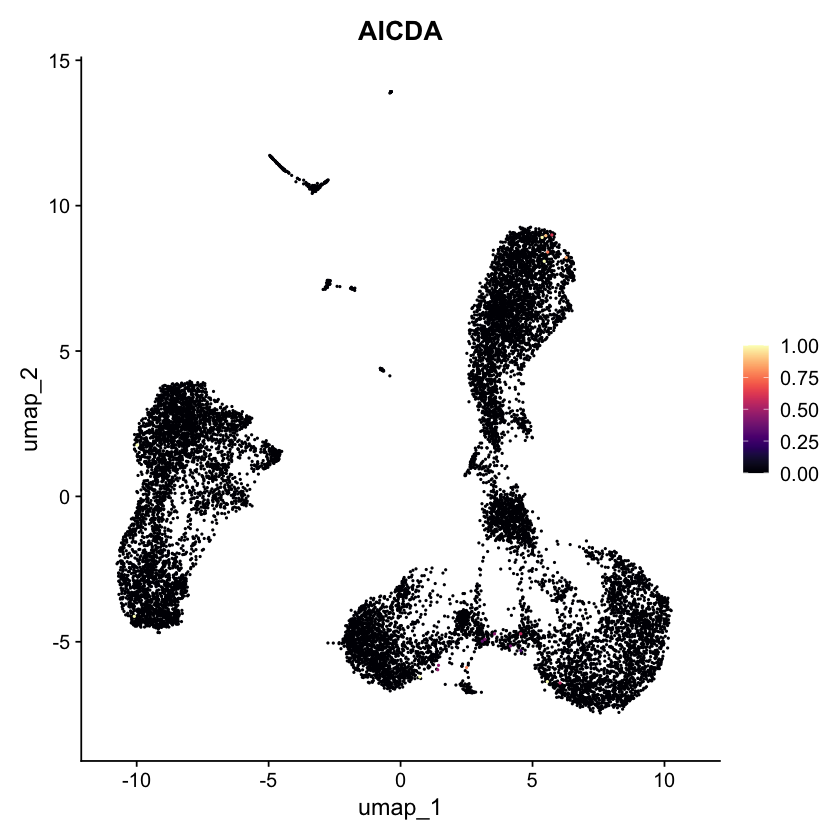

In [7]:
# ============================================================
# 6. Q1 — AID
# ============================================================
aicda <- FetchData(merged, vars = "AICDA")
merged$is_AID_positive <- aicda$AICDA > 0

cat("AICDA>0 (todas las células):", sum(merged$is_AID_positive),
    "=", round(100*mean(merged$is_AID_positive), 3), "%\n")
cat("\nAICDA>0 entre B tumorales, por tipo:\n")
print(table(merged$cell_type[merged$is_AID_positive & merged$is_tumorB]))

# Programa AID amplio (AICDA + maquinaria CSR/SHM)
aid_genes <- c("AICDA","UNG","APOBEC3A","APOBEC3B","APOBEC3C","APOBEC3G",
               "MSH2","MSH6","EXO1","POLH","PMS2","MLH1")
aid_genes <- aid_genes[aid_genes %in% rownames(merged)]
merged <- AddModuleScore(merged, features = list(aid_genes), name = "AID_program")

cat("\nScore medio del programa AID por tipo celular:\n")
print(round(sort(tapply(merged$AID_program1, merged$cell_type, mean),
                 decreasing = TRUE), 4))

FeaturePlot(merged, features = "AICDA", reduction = "umap",
            order = TRUE, min.cutoff = 0, max.cutoff = 1) &
  scale_color_viridis(option = "magma")

## 7. Q2 — ¿Hay subpoblación tumoral proliferativa?

Definimos proliferación con **MKI67** (gold standard), no con `Phase`, porque el `CellCycleScoring` previo dejó `Phase` ~1/3-1/3-1/3 (mal calibrado para este dataset).

MKI67+ en B tumorales: 21 = 0.23 %



MKI67+ por cluster:



       CLL_B CLL_B_plasma CLL_B_prolif 
           8            5            8 



MKI67+ por status:



 diagnosis refractory 
        14          7 


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


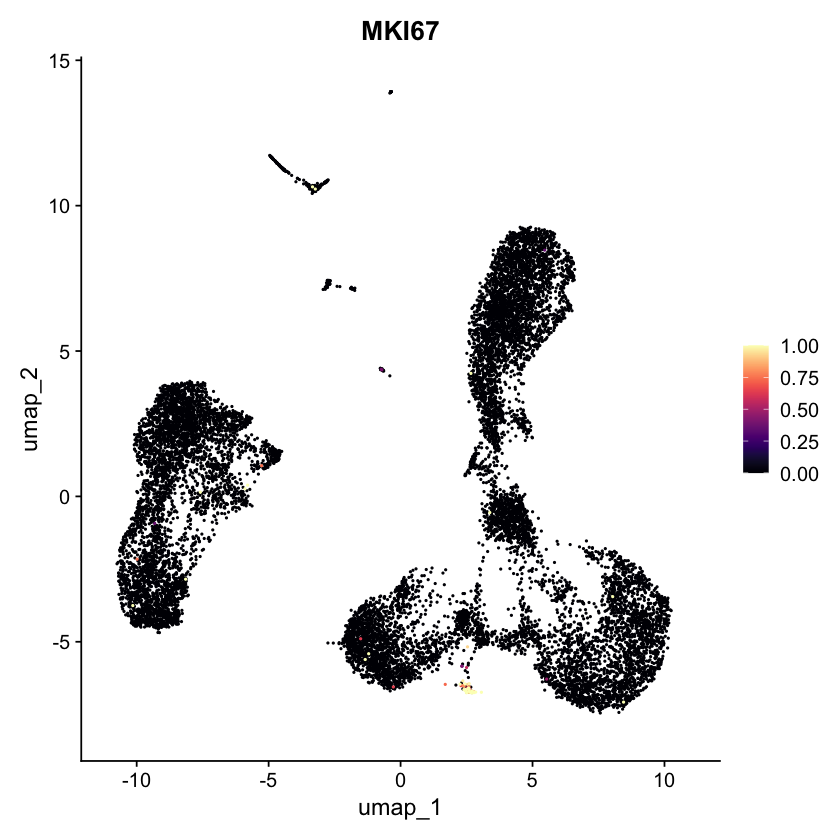

In [8]:
# ============================================================
# 7. Q2 — PROLIFERACIÓN
# ============================================================
mki67 <- FetchData(merged, vars = "MKI67")
merged$is_proliferating <- mki67$MKI67 > 0 & merged$is_tumorB

prolif_genes <- c("MKI67","TOP2A","PCNA","CCNB1","CDK1","STMN1","TYMS","HIST1H4C")
prolif_genes <- prolif_genes[prolif_genes %in% rownames(merged)]
merged <- AddModuleScore(merged, features = list(prolif_genes), name = "Prolif")

cat("MKI67+ en B tumorales:", sum(merged$is_proliferating),
    "=", round(100*sum(merged$is_proliferating)/sum(merged$is_tumorB), 2), "%\n")
cat("\nMKI67+ por cluster:\n")
print(table(merged$cell_type[merged$is_proliferating]))
cat("\nMKI67+ por status:\n")
print(table(merged$status[merged$is_proliferating]))

FeaturePlot(merged, features = "MKI67", reduction = "umap",
            order = TRUE, min.cutoff = 0, max.cutoff = 1) &
  scale_color_viridis(option = "magma")

## 8. Q3 — Vías IFN-α / IFN-γ / KRAS en B tumorales (Dx vs Ref, pooled)

Puntuamos cada célula con **AddModuleScore** para las 3 vías hipotetizadas, restringido a **B tumorales**, y comparamos diagnóstico vs refractario.

Warning message:
“The following features are not present in the object: CXCL10, CXCL11, WARS1, not searching for symbol synonyms”


Warning message:
“The following features are not present in the object: CCL2, CCL7, CXCL10, CXCL11, CXCL9, MARCHF1, RIGI, TMT1B, VCAM1, WARS1, not searching for symbol synonyms”


Warning message:
“The following features are not present in the object: ADGRL4, ALDH1A2, ANO1, ANXA10, ARG1, BTC, CFHR2, CIDEA, CPE, CXCL10, EPHB2, ETV4, GABRA3, GPNMB, H2BC3, HOXD11, IGF2, IL1RL2, IL33, INHBA, ITGBL1, LIF, MALL, MMP10, NGF, NR0B2, NR1H4, NRP1, PCP4, PEG3, PLVAP, RBP4, RELN, SCG3, SERPINA3, SLPI, SNAP25, SNAP91, SOX9, SPARCL1, SPP1, TMEM100, TNNT2, TSPAN1, TSPAN7, USH1C, not searching for symbol synonyms”


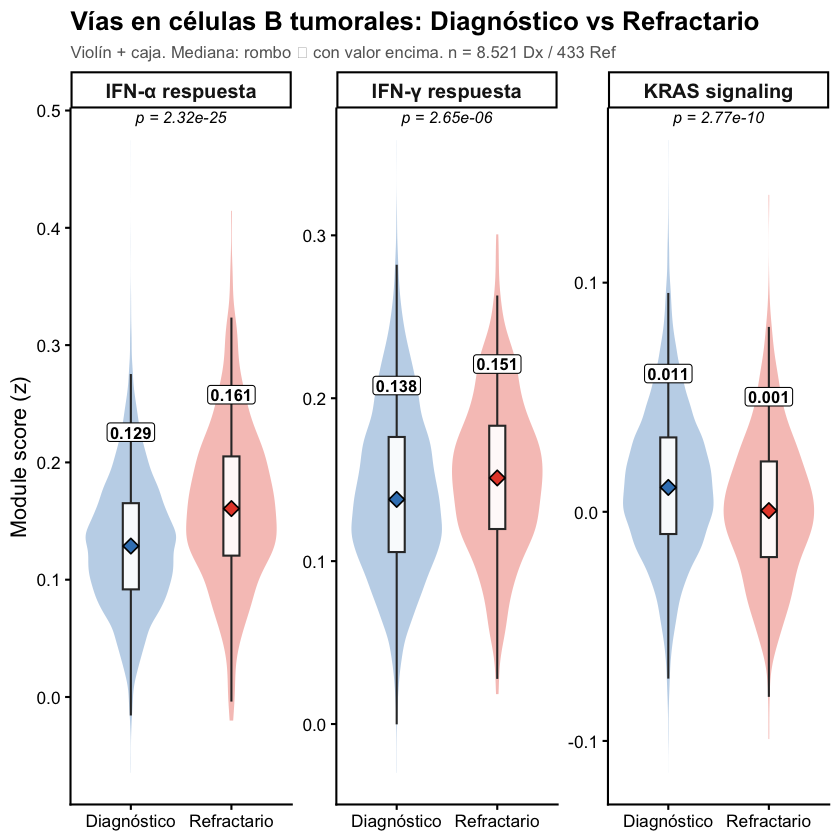

In [9]:
# ============================================================
# 8. Q3 — SCORES DE VÍA
# ============================================================
hallmark <- msigdbr(species = "Homo sapiens", collection = "H")
get_genes <- function(nm) unique(hallmark$gene_symbol[hallmark$gs_name == nm])

merged <- AddModuleScore(merged, features = list(get_genes("HALLMARK_INTERFERON_ALPHA_RESPONSE")), name = "IFNa")
merged <- AddModuleScore(merged, features = list(get_genes("HALLMARK_INTERFERON_GAMMA_RESPONSE")), name = "IFNg")
merged <- AddModuleScore(merged, features = list(get_genes("HALLMARK_KRAS_SIGNALING_UP")),     name = "KRAS")

tumor <- subset(merged, subset = is_tumorB == TRUE)

# Violín + caja + mediana etiquetada (visualización más legible para comparar)
df <- FetchData(tumor, vars = c("status", "IFNa1", "IFNg1", "KRAS1"))
df$status <- ifelse(df$status == "diagnosis", "Diagnóstico", "Refractario")
long <- df %>%
  pivot_longer(-status, names_to = "pathway", values_to = "score") %>%
  mutate(pathway = recode(pathway,
    IFNa1 = "IFN-α respuesta", IFNg1 = "IFN-γ respuesta",
    KRAS1 = "KRAS signaling"))
long$pathway <- factor(long$pathway,
  levels = c("IFN-α respuesta", "IFN-γ respuesta", "KRAS signaling"))
long$status <- factor(long$status, levels = c("Diagnóstico", "Refractario"))

meds <- long %>% group_by(pathway, status) %>%
  summarise(med = median(score), .groups = "drop") %>%
  group_by(pathway) %>%
  mutate(rng = diff(range(long$score[long$pathway == pathway])),
         y_label = med + 0.18 * rng) %>%
  ungroup()
pvals <- long %>% group_by(pathway) %>%
  summarise(p = wilcox.test(score[status=="Diagnóstico"],
                            score[status=="Refractario"])$p.value, .groups = "drop") %>%
  mutate(label = paste0("p = ", formatC(p, format = "e", digits = 2)))

ggplot(long, aes(x = status, y = score, fill = status)) +
  geom_violin(trim = TRUE, alpha = 0.35, color = NA, scale = "width") +
  geom_boxplot(width = 0.16, outlier.shape = NA, alpha = 0.9,
               color = "grey20", fill = "white") +
  geom_point(data = meds, aes(x = status, y = med, fill = status),
             shape = 23, size = 3, color = "black", stroke = 0.7) +
  geom_label(data = meds, aes(x = status, y = y_label, label = sprintf("%.3f", med)),
             fill = "white", color = "black", size = 3.5, fontface = "bold",
             label.padding = unit(0.15, "lines"), inherit.aes = FALSE) +
  geom_text(data = pvals, aes(x = 1.5, y = Inf, label = label),
            vjust = 1.2, size = 3.4, inherit.aes = FALSE, fontface = "italic") +
  facet_wrap(~ pathway, scales = "free_y") +
  scale_fill_manual(values = c("Diagnóstico" = "#3B82BF", "Refractario" = "#E64B35")) +
  labs(x = NULL, y = "Module score (z)", fill = NULL,
       title = "Vías en células B tumorales: Diagnóstico vs Refractario",
       subtitle = "Violín + caja. Mediana: rombo ▾ con valor encima. n = 8.521 Dx / 433 Ref") +
  theme_classic(base_size = 13) +
  theme(legend.position = "none", strip.text = element_text(face = "bold", size = 12),
        plot.title = element_text(face = "bold"),
        plot.subtitle = element_text(color = "grey40", size = 10))

### 8a. Test estadístico (Wilcoxon + tamaño de efecto Cliff's δ + corrección BH)

Además del p-valor reportamos el **Cliff's delta** (correlación rank-biserial), que mide el **tamaño del efecto** en [-1, 1], y corregimos por comparaciones múltiples (BH) sobre las 3 vías hipotetizadas.

> Convención Cliff's δ: < 0.147 *negligible* · 0.147–0.33 *pequeño* · 0.33–0.474 *mediano* · > 0.474 *grande*.
> δ < 0 → mayor en **refractario**; δ > 0 → mayor en **diagnóstico**.

In [10]:
# ============================================================
# 8a. TEST ESTADÍSTICO COMPLETO
# ============================================================
cliff_delta <- function(x, y) {
  sum(outer(x, y, function(a,b) sign(a-b))) / (length(x) * length(y))
}

scores <- c("IFNa1","IFNg1","KRAS1","AID_program1","Prolif1")

full_res <- lapply(scores, function(s) {
  x <- tumor@meta.data[[s]][tumor$status == "diagnosis"]
  y <- tumor@meta.data[[s]][tumor$status == "refractory"]
  wt <- wilcox.test(x, y)
  data.frame(score = s,
             med_dx = median(x), med_ref = median(y),
             cliff_delta = cliff_delta(x, y),
             p_value = wt$p.value)
})
full_res <- do.call(rbind, full_res)

# Corrección BH sobre las 3 vías con hipótesis a priori
full_res$padj_bh <- NA
named <- full_res$score %in% c("IFNa1","IFNg1","KRAS1")
full_res$padj_bh[named] <- p.adjust(full_res$p_value[named], method = "BH")

print(full_res, row.names = FALSE)

        score      med_dx       med_ref  cliff_delta      p_value      padj_bh
        IFNa1  0.12867933  0.1606336743 -0.295987931 2.323981e-25 6.971944e-25
        IFNg1  0.13788768  0.1510707448 -0.133570017 2.653466e-06 2.653466e-06
        KRAS1  0.01063521  0.0005236604  0.179505707 2.773297e-10 4.159946e-10
 AID_program1 -0.02745475 -0.0350356556 -0.003329636 9.068189e-01           NA
      Prolif1  0.02765355  0.0474538690 -0.076772967 6.952095e-03           NA


### 8b. Comparación JUSTA: submuestreo de diagnóstico

El desbalance (≈8.500 Dx vs ≈430 Ref) **infla los p-valores** y puede **confundir por sujeto**. Para una comparación justa:

1. Submuestreamos las B tumorales de **diagnóstico** hasta igualar el **número de refractario por sujeto** (S457: 323, S477: 110) → 433 vs 433.
2. Repetimos con **20 semillas** distintas y reportamos la mediana del p-valor, el % de réplicas significativas y la mediana del Cliff's δ.

Esto responde directamente: *¿el efecto sobrevive con tamaños parejos y sin sesgo de sujeto?*

In [11]:
# ============================================================
# 8b. COMPARACIÓN JUSTA (submuestreo estratificado por sujeto)
# ============================================================
ref_cells <- colnames(tumor)[tumor$status == "refractory"]
dx_cells  <- colnames(tumor)[tumor$status == "diagnosis"]
ref_subj <- tumor$subject[ref_cells]
dx_subj  <- tumor$subject[dx_cells]
ref_n    <- table(ref_subj)
cat("Refractario por sujeto:\n"); print(ref_n)

fair_res <- lapply(scores, function(s) {
  pvals <- c(); deltas <- c()
  for (seed in 1:20) {
    set.seed(seed)
    sel <- unlist(lapply(names(ref_n), function(sb) {
      pool <- dx_cells[dx_subj == sb]
      sample(pool, size = min(as.integer(ref_n[sb]), length(pool)))
    }))
    x <- tumor@meta.data[[s]][match(sel, colnames(tumor))]
    y <- tumor@meta.data[[s]][match(ref_cells, colnames(tumor))]
    pvals  <- c(pvals,  wilcox.test(x, y)$p.value)
    deltas <- c(deltas, cliff_delta(x, y))
  }
  data.frame(score = s, n_dx = length(ref_cells), n_ref = length(ref_cells),
             median_p = median(pvals),
             prop_sig = mean(pvals < 0.05),
             median_delta = median(deltas))
})
fair_res <- do.call(rbind, fair_res)
print(fair_res, row.names = FALSE)

Refractario por sujeto:


ref_subj
S457 S477 
 323  110 


        score n_dx n_ref     median_p prop_sig median_delta
        IFNa1  433   433 2.647419e-25     1.00  -0.40808794
        IFNg1  433   433 1.375909e-23     1.00  -0.39314306
        KRAS1  433   433 3.160648e-04     1.00   0.14142163
 AID_program1  433   433 6.410534e-03     0.95   0.10704095
      Prolif1  433   433 3.598124e-01     0.00  -0.03597011


### 8b-cont. Visualización del subset justo (un sorteo representativo)

Misma figura de la sección 8, pero sobre el **submuestreo justo** (433 Dx vs 433 Ref, seed 1). Comparar con la sección 8 muestra cuánto cambia (o no) la conclusión al balancear por sujeto.

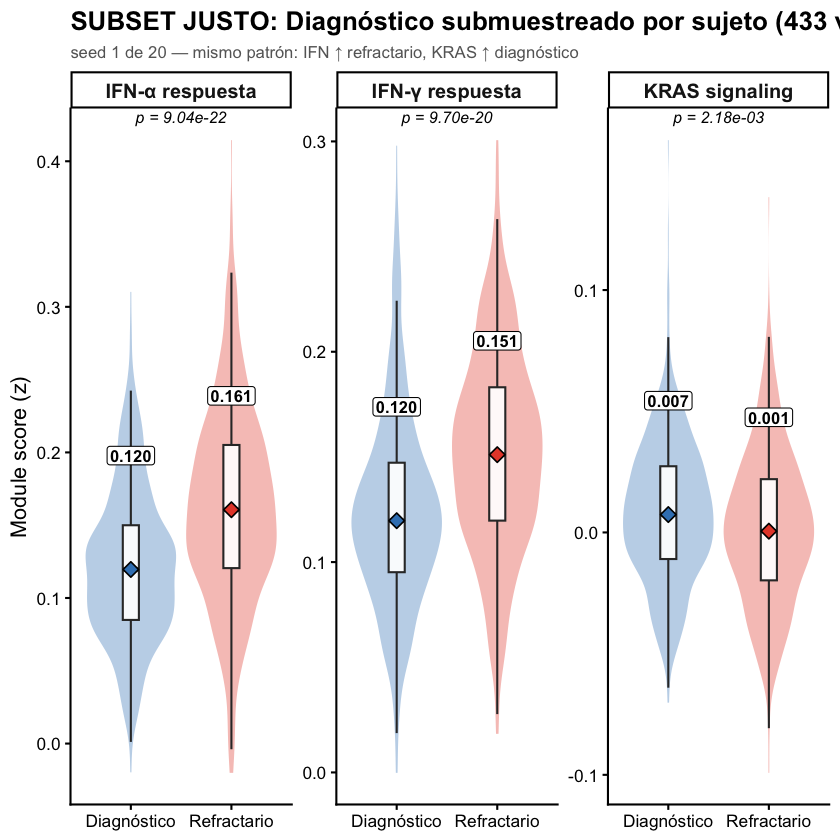

In [12]:
# ============================================================
# 8b-cont. FIGURA DEL SUBSET JUSTO
# ============================================================
set.seed(1)
sel <- unlist(lapply(names(ref_n), function(sb) {
  pool <- dx_cells[dx_subj == sb]
  sample(pool, size = min(as.integer(ref_n[sb]), length(pool)))
}))

df_sub <- FetchData(tumor, vars = c("status","IFNa1","IFNg1","KRAS1"))
df_sub <- df_sub[c(sel, ref_cells), ]
df_sub$status <- ifelse(df_sub$status == "diagnosis", "Diagnóstico", "Refractario")

long_sub <- df_sub %>%
  pivot_longer(-status, names_to = "pathway", values_to = "score") %>%
  mutate(pathway = recode(pathway,
    IFNa1 = "IFN-α respuesta", IFNg1 = "IFN-γ respuesta",
    KRAS1 = "KRAS signaling"))
long_sub$pathway <- factor(long_sub$pathway,
  levels = c("IFN-α respuesta", "IFN-γ respuesta", "KRAS signaling"))
long_sub$status <- factor(long_sub$status, levels = c("Diagnóstico", "Refractario"))

meds_sub <- long_sub %>% group_by(pathway, status) %>%
  summarise(med = median(score), .groups = "drop") %>%
  group_by(pathway) %>%
  mutate(rng = diff(range(long_sub$score[long_sub$pathway == pathway])),
         y_label = med + 0.18 * rng) %>% ungroup()
pvals_sub <- long_sub %>% group_by(pathway) %>%
  summarise(p = wilcox.test(score[status=="Diagnóstico"],
                            score[status=="Refractario"])$p.value, .groups = "drop") %>%
  mutate(label = paste0("p = ", formatC(p, format = "e", digits = 2)))

ggplot(long_sub, aes(x = status, y = score, fill = status)) +
  geom_violin(trim = TRUE, alpha = 0.35, color = NA, scale = "width") +
  geom_boxplot(width = 0.16, outlier.shape = NA, alpha = 0.9,
               color = "grey20", fill = "white") +
  geom_point(data = meds_sub, aes(x = status, y = med, fill = status),
             shape = 23, size = 3, color = "black", stroke = 0.7) +
  geom_label(data = meds_sub, aes(x = status, y = y_label, label = sprintf("%.3f", med)),
             fill = "white", color = "black", size = 3.5, fontface = "bold",
             label.padding = unit(0.15, "lines"), inherit.aes = FALSE) +
  geom_text(data = pvals_sub, aes(x = 1.5, y = Inf, label = label),
            vjust = 1.2, size = 3.4, inherit.aes = FALSE, fontface = "italic") +
  facet_wrap(~ pathway, scales = "free_y") +
  scale_fill_manual(values = c("Diagnóstico" = "#3B82BF", "Refractario" = "#E64B35")) +
  labs(x = NULL, y = "Module score (z)", fill = NULL,
       title = "SUBSET JUSTO: Diagnóstico submuestreado por sujeto (433 vs 433)",
       subtitle = "seed 1 de 20 — mismo patrón: IFN ↑ refractario, KRAS ↑ diagnóstico") +
  theme_classic(base_size = 13) +
  theme(legend.position = "none", strip.text = element_text(face = "bold", size = 12),
        plot.title = element_text(face = "bold"),
        plot.subtitle = element_text(color = "grey40", size = 10))

### 8c. GSEA (fgsea) sobre el ranking génico

Complemento al score por célula: rankeamos **todos** los genes por diferencia de medias (Dx − Ref) y testeamos enriquecimiento de gene-sets Hallmark.

> NES > 0 = enriquecido en **diagnóstico**; NES < 0 = enriquecido en **refractario**.

In [13]:
# ============================================================
# 8c. GSEA (fgsea)
# ============================================================
hallmark_sets <- msigdbr(species = "Homo sapiens", collection = "H") %>%
  split(x = .$gene_symbol, f = .$gs_name)

mat <- GetAssayData(tumor, layer = "data")
lfc <- rowMeans(mat[, tumor$status == "diagnosis", drop = FALSE]) -
       rowMeans(mat[, tumor$status == "refractory", drop = FALSE])
lfc <- sort(lfc[is.finite(lfc)], decreasing = TRUE)

gsea_h <- fgsea(pathways = hallmark_sets, stats = lfc, minSize = 15, maxSize = 500, eps = 0)
gsea_h <- gsea_h[order(gsea_h$pval), ]

cat("Top 15 vías Hallmark (padj<0.25):\n")
gsea_h %>% filter(padj < 0.25) %>%
  select(pathway, NES, pval, padj) %>% head(15)

cat("\nVías hipotetizadas (IFN-α, IFN-γ, KRAS):\n")
gsea_h %>% filter(grepl("INTERFERON_ALPHA|INTERFERON_GAMMA|KRAS", pathway)) %>%
  select(pathway, NES, pval, padj)

Warning message in prepareStats(stats, scoreType, gseaParam):
“There are ties in the preranked stats (0.26% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


Top 15 vías Hallmark (padj<0.25):


pathway,NES,pval,padj
<chr>,<dbl>,<dbl>,<dbl>
HALLMARK_OXIDATIVE_PHOSPHORYLATION,1.605245,7.226110e-07,3.613055e-05
HALLMARK_TNFA_SIGNALING_VIA_NFKB,1.442818,2.693196e-03,6.504207e-02
HALLMARK_HYPOXIA,1.428440,3.902524e-03,6.504207e-02
HALLMARK_MTORC1_SIGNALING,1.371898,5.451251e-03,6.635429e-02
HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,1.413504,1.042565e-02,6.635429e-02
HALLMARK_GLYCOLYSIS,1.369289,1.062002e-02,6.635429e-02
HALLMARK_P53_PATHWAY,1.356419,1.230693e-02,6.635429e-02
HALLMARK_ALLOGRAFT_REJECTION,1.368458,1.244879e-02,6.635429e-02
HALLMARK_MYC_TARGETS_V1,1.362884,1.292420e-02,6.635429e-02



Vías hipotetizadas (IFN-α, IFN-γ, KRAS):


pathway,NES,pval,padj
<chr>,<dbl>,<dbl>,<dbl>
HALLMARK_KRAS_SIGNALING_DN,-1.3167164,0.1081838,0.2846942
HALLMARK_KRAS_SIGNALING_UP,1.2305607,0.1144708,0.2861771
HALLMARK_INTERFERON_ALPHA_RESPONSE,-1.0556742,0.3193277,0.5301029
HALLMARK_INTERFERON_GAMMA_RESPONSE,0.9303491,0.6483871,0.7502831


### 8d. Pseudobulk DESeq2 (n = 4 muestras)

Test formal a **nivel de muestra** (agrega todas las células de cada muestra en un perfil), con diseño `~ subject + status` para controlar la variación entre pacientes.

> **Caveat:** con n = 4 es de **baja potencia** y muy sensible a contaminación ambiental (el compartimento refractario es minúsculo). Se reporta como apoyo, no como evidencia principal.

In [14]:
# ============================================================
# 8d. PSEUDOBULK DESeq2 (genes filtrados)
# ============================================================
# Se eliminan genes no informativos para DE: inmunoglobulinas (IGH/IGK/IGL/
# JCHAIN), TCR (TRA/TRB/TRD/TRG), mitocondriales (MT-), ribosomales (RPS/RPL)
# y hemoglobinas (HBA/HBB). Dominan la señal o reflejan contaminación/identidad
# clonal, no biología de la vía.
drop_re <- "^(IGH|IGK|IGL|IGJ|JCHAIN|TRA|TRB|TRD|TRG|MT-|MT|RPS|RPL|HBA|HBB|HBD|HBG|HBE|HBZ|MALAT1)"
tumor_f <- tumor[!grepl(drop_re, rownames(tumor)), ]

pb <- AggregateExpression(tumor_f, assays = "RNA", slot = "counts",
                          group.by = "sample_id", return.seurat = FALSE)$RNA
colnames(pb) <- gsub("-", "_", colnames(pb))

md <- unique(tumor@meta.data[, c("sample_id", "status", "subject")])
rownames(md) <- md$sample_id
md <- md[colnames(pb), ]
md$status <- factor(md$status, levels = c("refractory", "diagnosis"))

dds <- DESeqDataSetFromMatrix(countData = round(pb), colData = md,
                              design = ~ subject + status)
dds <- DESeq(dds, quiet = TRUE)
res <- results(dds, contrast = c("status", "diagnosis", "refractory")) %>%
  as.data.frame() %>% rownames_to_column("gene") %>% arrange(padj)

cat("Genes DE (padj<0.05):", sum(res$padj < 0.05, na.rm = TRUE), "\n")
head(res %>% select(gene, log2FoldChange, padj), 15)

Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


converting counts to integer mode



Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


Genes DE (padj<0.05): 19 


,gene,log2FoldChange,padj
,<chr>,<dbl>,<dbl>
1,PRSS2,-8.287626,1.197946e-10
2,GNLY,-4.125367,8.967848e-05
3,HCK,-6.462408,1.181167e-04
4,BMP3,-8.453001,3.799669e-03
5,SOX4,-6.333369,3.799669e-03
6,MARCKS,-3.283496,3.799669e-03
7,CDK6,-5.842473,3.799669e-03
8,GAS6,-3.969743,3.799669e-03
9,CD9,-4.454043,4.616288e-03


## 9. Guardar resultados

In [15]:
# ============================================================
# 9. GUARDAR RESULTADOS
# ============================================================
dir.create("results", showWarnings = FALSE)
saveRDS(merged, "results/CLL_scRNAseq_merged_annotated.rds")

meta_out <- merged@meta.data %>%
  select(subject, sample_id, status, chip, celltype_demux, cell_type,
         is_tumorB, is_AID_positive, AID_program1,
         is_proliferating, Prolif1, IFNa1, IFNg1, KRAS1)
write.csv(meta_out, "results/cell_annotation_metadata.csv")

write.csv(full_res, "results/Q3_pathway_scores_dx_vs_ref.csv", row.names = FALSE)
write.csv(fair_res, "results/Q3_pathway_scores_fair_downsampled.csv", row.names = FALSE)
write.csv(as.data.frame(gsea_h)[, setdiff(names(gsea_h), "leadingEdge")],
          "results/GSEA_Hallmark_Dx_vs_Ref_pooled.csv", row.names = FALSE)
write.csv(res, "results/DESeq2_pseudobulk_Dx_vs_Ref_pooled.csv", row.names = FALSE)

message("Resultados guardados en results/")

Resultados guardados en results/



## 10. Conclusiones

**Q1 — AID.** AICDA se detecta en solo **20/14.550 células (0,14%)**, de las cuales **17 son B tumorales** (9 CLL_B, 2 CLL_B_plasma, 6 CLL_B_prolif). AID+ **no es un cluster propio**: es una subpoblación rara dispersa en B tumorales, con el programa AID (score 0.030) **enriquecido en el cluster proliferativo CLL_B_prolif** (cluster 6).

**Q2 — Proliferación.** Sí hay subpoblación proliferativa: **cluster 6 (CLL_B_prolif, ≈600 células)** concentra MKI67/TOP2A/PCNA/STMN1. La fracción MKI67+ en B tumorales es **≈0,2%** (21 células), coherente con la quiescencia típica de la CLL.

**Q3 — Vías (Dx vs Ref, solo B tumorales, pooled).** Con la **comparación justa** (submuestreo, 433 vs 433, 20 semillas):
- **IFN-α y IFN-γ: mayor en refractario** (Cliff δ ≈ −0,41 / −0,39; 100% de réplicas p<0,05) → efecto **mediano**, robusto.
- **KRAS: mayor en diagnóstico** (Cliff δ ≈ +0,14; 100% p<0,05) → efecto **pequeño**.
- **GSEA a nivel de gene-set:** el **diagnóstico** muestra un programa **metabólico/proliferativo** coherente: **OXPHOS** (NES 1.61, padj 3e-5), glicólisis, mTORC1, MYC targets, p53, DNA repair, y **RIBOSOMA** (KEGG, NES 1.92, padj 1e-21) — traducción y biogénesis ribosomal elevadas. IFN no sale significativo al ranking global (efecto diluido, pero en dirección coherente con el score por célula).
- **Pseudobulk DESeq2 (n=4):** tras filtrar IG/TCR/mito/ribo/hb, los DE bajan de 39 a **19 genes**. ↑ diagnóstico: **JUN, TSC22D3, OTUD1**; ↑ refractario: **CDK6, SOX4, HCK, CD9, MARCKS, GAS6** (más GNLY/GZMB = contaminación NK residual). Baja confianza por n=4 y contaminación clonal.

**Lectura biológica:** el compartimento B tumoral refractario muestra una firma de **respuesta a interferón (IFN-α/γ) aumentada** respecto al diagnóstico, mientras que el diagnóstico muestra **KRAS y OXPHOS** más altos — patrón consistente con la exposición al ibrutinib y la presión selectiva del microambiente.